In [266]:
import numpy as np
from matplotlib import pyplot as plt
from scipy import stats
from astropy.visualization import hist
from scipy.stats import norm
import scipy
import astroML.stats
from numpy.random import choice


In [160]:
def probability(tomorrow,today):
    if (today==0) & (tomorrow==0): return 0.5
    elif (today==0) & (tomorrow==1): return 0.5
    elif (today==1) & (tomorrow==0): return 0.1
    elif (today==1) & (tomorrow==1): return 0.9

#today cloudy, tomorrow cloudy: 0,0
#today cloudy, tomorrow clear: 1,0

def jump(today):
    if (today==0):
        draw = choice([0,1],1,p=[probability(0,today),probability(1,today)],replace=False)
        
    else: 
        draw = choice([0,1],1,p=[probability(0,today),probability(1,today)],replace=False)

    return draw[0]
def jump(today):
    if (today==0):
        draw = choice([0,1],1,p=[0.5,0.5],replace=False)
        
    elif (today==1): 
        draw = choice([0,1],1,p=[0.1,0.9],replace=False)

    return draw[0]

In [161]:
#devo fare in modo che a ogni estrazione le probabilità siano rispettate: non può essere deterministico
(jump(0))

1

In [236]:
N=200000
p_init = 1
p_current = p_init
posterior = [p_current]
clear_counter=[p_init]


for i in range(N):
    p_current = jump(p_current)
    posterior = np.append(posterior,p_current)
    clear_counter = np.append(clear_counter,posterior.sum())


In [237]:
burn_in = 12000


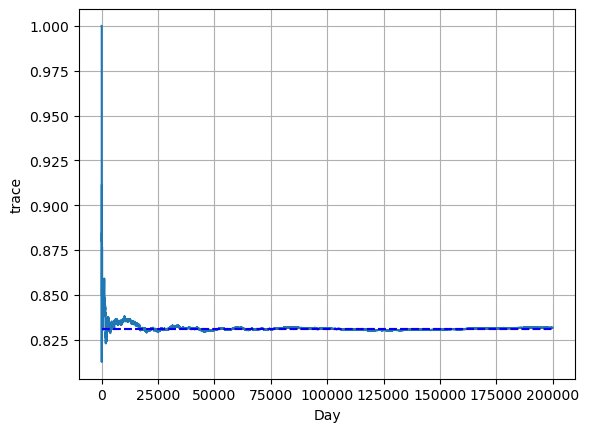

In [264]:
freq_clear = clear_counter/np.arange(1,N+2)
plt.plot(np.arange(1,N+2),freq_clear)
plt.xlabel('Day')
plt.ylabel('trace')
plt.hlines(np.mean(freq_clear[burn_in:]),0,N,linestyle='--',color='r')
plt.hlines(np.median(freq_clear[burn_in:]),0,N,linestyle='--',color='b')
plt.grid()

In [267]:
print(np.median(freq_clear))
print(astroML.stats.sigmaG(freq_clear))

0.8309816715847221
0.000613652267980653


[]

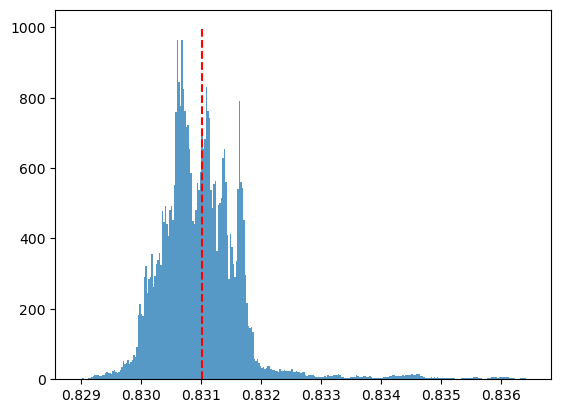

In [259]:
plt.hist(freq_clear[burn_in:],300,alpha=0.75,density=True)
plt.vlines(np.mean(freq_clear[burn_in:]),0,1000,linestyle='--',color='r')
plt.plot()